In [1]:
!pip install matplotlib scikit-learn

# Connecting to google drive to load the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing necessary libraries

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision import models
from tqdm import tqdm
from torchvision import models
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import os
from transformers import get_cosine_schedule_with_warmup

# Custom dataloader class and transforms

In [4]:

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])



test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])])

In [5]:
class Car_Dataset(Dataset):
  def __init__(self, dir_path, transform=None):
    self.data = ImageFolder(dir_path, transform=transform)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    return self.data[index]

In [6]:
train_path = "/content/drive/MyDrive/dataset/train"
test_path  = "/content/drive/MyDrive/dataset/val"


train_set = Car_Dataset(dir_path=train_path, transform=train_transforms)
test_set  = Car_Dataset(dir_path=test_path, transform=test_transforms)

In [7]:
class_to_idx = train_set.data.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
idx_to_class

{0: 'F_Breakage',
 1: 'F_Crushed',
 2: 'F_Normal',
 3: 'R_Breakage',
 4: 'R_Crushed',
 5: 'R_Normal'}

# Visualising the train test split

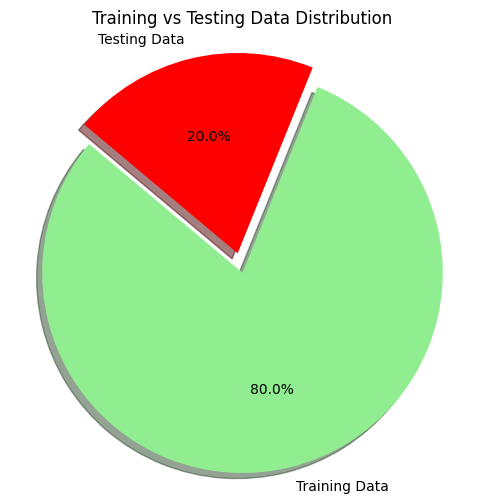

In [8]:
labels = ['Training Data', 'Testing Data']
sizes  = [len(train_set), len(test_set)]
colors = ['lightgreen', 'red']
explode = (0.1, 0)
plt.figure(figsize=(6, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Training vs Testing Data Distribution')
plt.axis('equal')
plt.show()

# Ploting the image distribution across the classes

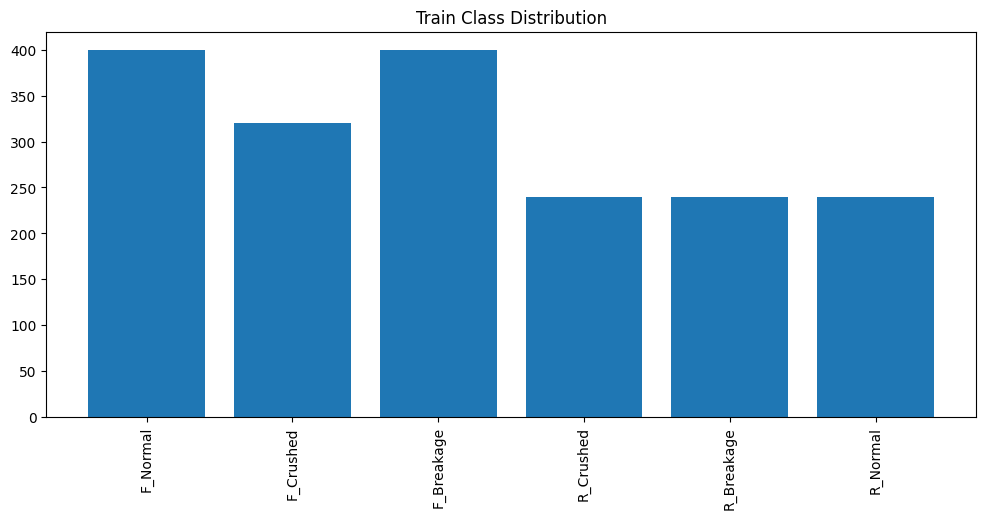

In [9]:
def plot_class_distribution(data_path):
    classes = os.listdir(data_path)
    counts = []

    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        if os.path.isdir(cls_path):
            counts.append(len(os.listdir(cls_path)))

    plt.figure(figsize=(12,5))
    plt.bar(classes, counts)
    plt.xticks(rotation=90)
    plt.title("Train Class Distribution")
    plt.show()

plot_class_distribution("/content/drive/MyDrive/dataset/train")

In [14]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)

eval_loader = DataLoader(test_set, batch_size=64, num_workers=8, pin_memory=True, persistent_workers=True)

# Initializing the model

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [15]:
class Car_Classifier_Resnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = models.resnet18(weights="DEFAULT")

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer3.parameters():
            param.requires_grad = True

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Again using different LR for classifier and unfreezed layers

In [18]:
model = Car_Classifier_Resnet(num_classes=len(class_to_idx)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {"params": model.model.layer3.parameters(), "lr": 1e-5},
    {"params": model.model.layer4.parameters(), "lr": 1e-5},
    {"params": model.model.fc.parameters(), "lr": 1e-4}
])

# Early Stopping

In [19]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter    = 0

# Training Function

In [20]:
def train_model(
    model,
    epochs,
    train_loader,
    eval_loader,
    optimizer,
    criterion,
    device,
    patience=7,
    checkpoint_model_name="model"
):

    print("Starting training...")
    print(f"Epochs: {epochs} | Device: {device}")
    print("-" * 60)

    # ------------------------- SCHEDULER -------------------------
    num_training_steps = epochs * len(train_loader)
    num_warmup_steps   = int(0.1 * num_training_steps)

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    early_stopping = EarlyStopping(patience=patience)

    train_losses, train_accs = [], []
    val_losses,   val_accs   = [], []

    best_acc = 0.0

    # ------------------------- TRAIN LOOP -------------------------
    for epoch in range(epochs):

        # --------------------- TRAIN ---------------------
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss   = criterion(logits, labels)
            loss.backward()

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            preds   = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # --------------------- VALIDATION ---------------------
        model.eval()
        val_running_loss, val_correct, val_total = 0, 0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in tqdm(eval_loader, desc=f"Epoch {epoch+1} Validation"):
                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)
                loss   = criterion(logits, labels)

                val_running_loss += loss.item()
                preds   = torch.argmax(logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total   += labels.size(0)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(eval_loader)
        val_acc  = 100 * val_correct / val_total

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(
            f"Results | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% || "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
        )
        print("-" * 60)

        # --------------------- SAVE BEST MODEL (BY ACCURACY) ---------------------
        if val_acc > best_acc:
            best_acc = val_acc
            os.makedirs("checkpoints", exist_ok=True)
            torch.save({
                "model_state_dict":     model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch":                epoch,
                "val_acc":              val_acc
            }, f"checkpoints/{checkpoint_model_name}.pt")
            print(f"  Best model saved (Acc: {val_acc:.2f}%)")

        # --------------------- EARLY STOPPING ---------------------
        early_stopping(val_acc)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    return train_losses, train_accs, val_losses, val_accs, all_preds, all_labels

# Train the Model

In [21]:
train_losses, train_accuracy, eval_losses, eval_accuracies, all_preds, all_labels = train_model(
    model                 = model,
    train_loader          = train_loader,
    eval_loader           = eval_loader,
    optimizer             = optimizer,
    criterion             = criterion,
    device                = device,
    epochs                = 100,
    patience              = 7,
    checkpoint_model_name = 'best_resnet_model'
)

Starting training...
Epochs: 100 | Device: cuda
------------------------------------------------------------


Epoch 1 Training:   0%|          | 0/29 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1 Validation: 100%|██████████| 8/8 [00:26<00:00,  3.36s/it]


Results | Train Loss: 1.8359 | Train Acc: 17.34% || Val Loss: 1.7960 | Val Acc: 22.39%
------------------------------------------------------------
  Best model saved (Acc: 22.39%)


Epoch 2 Validation: 100%|██████████| 8/8 [00:05<00:00,  1.36it/s]


Results | Train Loss: 1.8131 | Train Acc: 20.05% || Val Loss: 1.7694 | Val Acc: 28.70%
------------------------------------------------------------
  Best model saved (Acc: 28.70%)


...

Results | Train Loss: 0.1638 | Train Acc: 94.24% || Val Loss: 0.7279 | Val Acc: 75.00%
------------------------------------------------------------
  EarlyStopping: 5/7


Epoch 47 Validation: 100%|██████████| 8/8 [00:07<00:00,  1.05it/s]


Results | Train Loss: 0.1735 | Train Acc: 94.13% || Val Loss: 0.7278 | Val Acc: 75.43%
------------------------------------------------------------
  EarlyStopping: 6/7


Epoch 48 Validation: 100%|██████████| 8/8 [00:06<00:00,  1.29it/s]

Results | Train Loss: 0.1694 | Train Acc: 94.02% || Val Loss: 0.7269 | Val Acc: 75.65%
------------------------------------------------------------
  EarlyStopping: 7/7
Early stopping at epoch 48


# Plotting Loss and Accuracy Curves

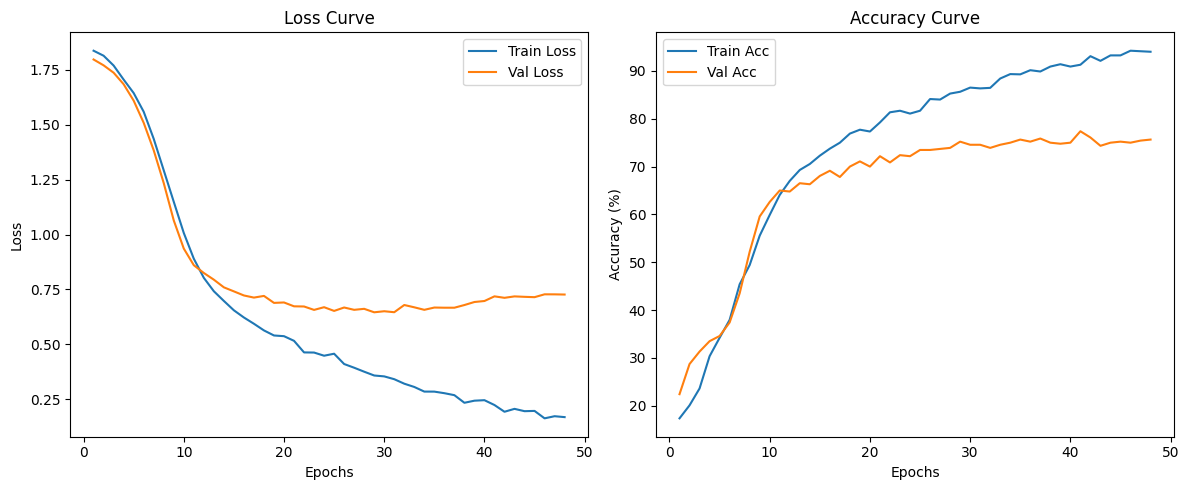

In [22]:
def plot_training_curves(train_losses, eval_losses, train_acc, eval_acc):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, eval_losses,  label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, eval_acc,  label="Val Acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(train_losses, eval_losses, train_accuracy, eval_accuracies)

# Evaluation — Load Best Model & Run Predictions

In [23]:
loaded_model = Car_Classifier_Resnet(num_classes=len(class_to_idx)).to(device)

checkpoint_path = "checkpoints/best_resnet_model.pt"
checkpoint = torch.load(checkpoint_path)
loaded_model.load_state_dict(checkpoint['model_state_dict'])

print(f"Best model loaded from {checkpoint_path}")
print(f"  Saved at epoch {checkpoint['epoch'] + 1} | Val Acc: {checkpoint['val_acc']:.2f}%")

loaded_model.eval()

all_labels_loaded_model = []
all_preds_loaded_model  = []

with torch.no_grad():
    for images, labels in tqdm(eval_loader, desc="Making predictions on eval_loader"):
        images = images.to(device)
        labels = labels.to(device)

        logits = loaded_model(images)
        preds  = torch.argmax(logits, dim=1)

        all_labels_loaded_model.extend(labels.cpu().numpy())
        all_preds_loaded_model.extend(preds.cpu().numpy())

Best model loaded from checkpoints/best_resnet_model.pt
  Saved at epoch 41 | Val Acc: 77.39%


Making predictions on eval_loader: 100%|██████████| 8/8 [00:05<00:00,  1.46it/s]


# Metrics — Accuracy, Precision, Recall, Confusion Matrix & Classification Report


=== Results from LOADED best model ===
  Overall Accuracy  : 77.39%
  Weighted Precision: 78.19%
  Weighted Recall   : 77.39%

--- Classification Report ---
              precision    recall  f1-score   support

  F_Breakage       0.83      0.78      0.80       100
   F_Crushed       0.63      0.75      0.69        80
    F_Normal       0.89      0.85      0.87       100
  R_Breakage       0.81      0.72      0.76        60
   R_Crushed       0.67      0.72      0.69        60
    R_Normal       0.81      0.78      0.80        60

    accuracy                           0.77       460
   macro avg       0.77      0.77      0.77       460
weighted avg       0.78      0.77      0.78       460

--- Confusion Matrix ---


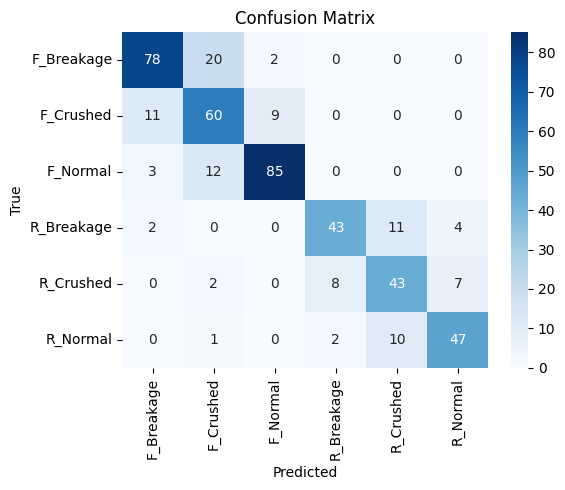

In [24]:
def print_metrics(all_labels, all_preds):
    class_names = train_set.data.classes

    acc       = accuracy_score(all_labels, all_preds) * 100
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0) * 100

    print("=" * 60)
    print(f"  Overall Accuracy  : {acc:.2f}%")
    print(f"  Weighted Precision: {precision:.2f}%")
    print(f"  Weighted Recall   : {recall:.2f}%")
    print("=" * 60)

    print("\n--- Classification Report ---")
    report = classification_report(all_labels, all_preds, target_names=class_names, zero_division=0)
    print(report)

    print("--- Confusion Matrix ---")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(max(6, len(class_names)), max(5, len(class_names) - 1)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

print("\n=== Results from LOADED best model ===")
print_metrics(all_labels_loaded_model, all_preds_loaded_model)

# Uploading the model to HF

In [28]:
import os
from huggingface_hub import HfApi, notebook_login
import torch

# 1. Install huggingface_hub (if not already installed)
!pip install huggingface_hub -q

# 2. Log in to Hugging Face Hub
# You will be prompted to enter your Hugging Face token.
# You can find your token at https://huggingface.co/settings/tokens
notebook_login()

# 3. Define the repository ID and model name
hf_username = "junaid17"
model_name = "car-damage-classifier"
repo_id = f"{hf_username}/{model_name}"

# 4. Save the model's state_dict
# The `loaded_model` from the previous cells is the best performing model.
model_save_path = f"./{model_name}.pt"
torch.save(loaded_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# 5. Push the saved model to Hugging Face Hub
api = HfApi()

# Create the repository if it doesn't exist
api.create_repo(repo_id=repo_id, exist_ok=True, private=False)

# Upload the model file
api.upload_file(
    path_or_fileobj=model_save_path,
    path_in_repo=f"{model_name}.pt",
    repo_id=repo_id,
    repo_type="model",
)

print(f"Model '{model_name}.pt' uploaded to https://huggingface.co/{repo_id}")

Model saved to ./car-damage-classifier.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ./car-damage-classifier.pt  :   1%|1         |  567kB / 45.3MB            

Model 'car-damage-classifier.pt' uploaded to https://huggingface.co/junaid17/car-damage-classifier
